# Notebook 10 - Parte VII: análisis crítico, escalabilidad y equidad

## Qué cubre del enunciado
La Parte VII (pág. 3) pide comparar **exactitud vs eficiencia**, analizar complejidad de tiempo/espacio, decidir qué escala y reflexionar sobre **subrepresentación, reseñas falsas, equidad, diversidad y pequeños negocios frente a grandes actores**. Este notebook transforma cada punto en evidencia cuantitativa y conecta los resultados de las Partes I-VI.

## Fundamento teórico
- **Streams:** una pasada, memoria limitada y aproximaciones con garantías - deck 06, págs. 4 y 6; DGIM - pág. 21; Count-Min Sketch - pág. 34.
- **Grafos:** PageRank debe usar una representación dispersa; la matriz densa es inviable y cada iteración recorre el grafo - deck 07, págs. 35 y 38. Girvan-Newman cuesta $O(m^2n)$ - deck 12, pág. 23.
- **Clustering:** la elección depende del tradeoff entre escalabilidad, flexibilidad, tiempo y memoria - deck 08, pág. 2; la alta dimensión concentra distancias - pág. 7; BFR resume bloques mediante DS/CS/RS - págs. 33-42.
- **Reducción:** el compromiso exactitud-eficiencia guía la elección de una representación de bajo rango - deck 13, pág. 69.
- **Recomendación:** Pearson corrige tendencia individual al puntuar - deck 09, pág. 30; completar vacíos para SVD introduce sesgo - deck 10, pág. 20.

## Principio de interpretación responsable
Yelp no contiene atributos protegidos ni propiedad empresarial. Por eso usamos tres **proxies descriptivos**, nunca causales: reseñas acumuladas = visibilidad histórica; repetición del nombre = presencia multi-local; ingreso ACS del ZIP = contexto del área, no ingreso de una persona. Toda conclusión mantiene esa frontera explícita.


In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append("..")
from pathlib import Path
from time import perf_counter

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import clustering as cl
from src import critical_analysis as ca
from src import recommenders as rec
from src import viz
from src.config import GOLD, ROOT, SEED

viz.aplicar_estilo()
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
P = viz.PALETA


## 1. Cómo se construyó la evidencia: el aporte progresivo de I-VI

La Parte VII no es un apéndice separado. Cada parte anterior añade capacidad y, al mismo tiempo, revela un riesgo nuevo. La tabla funciona como mapa de trazabilidad: **dato -> método -> hallazgo -> riesgo -> auditoría**.


In [2]:
contribuciones = pd.DataFrame([
    ["I", "EDA + gold", "Universo íntegro y reproducible", "La voz está concentrada; atributos faltantes", "Concentración y calidad por contexto"],
    ["II", "PageRank, HITS, comunidades", "Influencia y estructura más allá del conteo", "Popularidad y usuarios Elite pueden amplificarse", "Representación en la cabeza de rankings"],
    ["III", "K-Means++, DBSCAN, BFR", "Seis perfiles operativos y límites de densidad", "Distancias fallan en 42D; ACS es contexto ecológico", "Clusters por ingreso ZIP y faltantes"],
    ["IV", "CF, contenido, híbrido", "Ranking personalizado con evaluación temporal", "Feedback loop y exposición desigual", "Cobertura, concentración y visibilidad"],
    ["V", "Ventanas, CMS, DGIM", "Procesamiento de 20.35M eventos con memoria acotada", "La aproximación tiene error; existe concept drift", "Error/garantía y escalabilidad"],
    ["VI", "PCA, SVD", "Compresión y factores latentes interpretables", "Reducir dimensiones también borra señal", "Pérdida de información vs memoria"],
], columns=["parte", "evidencia", "aporte", "riesgo_que_revela", "uso_en_VII"])
display(contribuciones)


,parte,evidencia,aporte,riesgo_que_revela,uso_en_VII
0,I,EDA + gold,Universo íntegro y reproducible,La voz está concentrada; atributos faltantes,Concentración y calidad por contexto
1,II,"PageRank, HITS, comunidades",Influencia y estructura más allá del conteo,Popularidad y usuarios Elite pueden amplificarse,Representación en la cabeza de rankings
2,III,"K-Means++, DBSCAN, BFR",Seis perfiles operativos y límites de densidad,Distancias fallan en 42D; ACS es contexto ecol...,Clusters por ingreso ZIP y faltantes
3,IV,"CF, contenido, híbrido",Ranking personalizado con evaluación temporal,Feedback loop y exposición desigual,"Cobertura, concentración y visibilidad"
4,V,"Ventanas, CMS, DGIM",Procesamiento de 20.35M eventos con memoria ac...,La aproximación tiene error; existe concept drift,Error/garantía y escalabilidad
5,VI,"PCA, SVD",Compresión y factores latentes interpretables,Reducir dimensiones también borra señal,Pérdida de información vs memoria


En lenguaje simple: cada técnica mejora una decisión, pero ninguna es neutral. PageRank decide qué conexión importa; clustering decide qué diferencias conservar; el recomendador decide quién recibe atención; CMS y SVD deciden qué información puede perderse para ganar escala. La auditoría evalúa esas decisiones con el mismo rigor que las métricas de precisión.


## 2. Escalabilidad: medir el cuello de botella, no adivinarlo

Combinamos tres niveles de evidencia:

1. complejidad teórica de las diapositivas;
2. tiempos reales ya obtenidos en los notebooks;
3. un microbenchmark sobre las **42 features reales**, comparando el kernel lineal de asignación a centroides con la búsqueda cuadrática de vecindades.

El microbenchmark procesa por bloques: evita una explosión de memoria, pero no cambia la cantidad cuadrática de distancias. Esa diferencia entre **reducir memoria** y **reducir trabajo** es central.


docs/figs/parte7_escalabilidad_tradeoffs.png


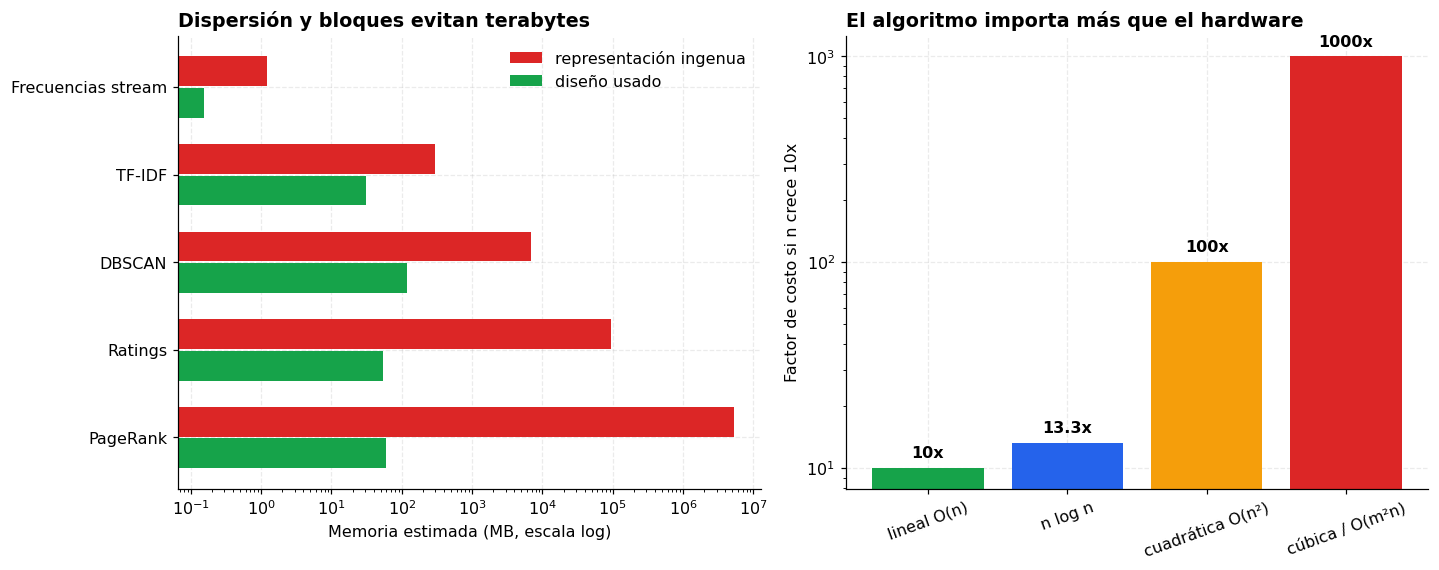

            kernel    n segundos  conteo_control pendiente_loglog
asignación K-Means  500 0.000046             NaN             1.20
 vecindades DBSCAN  500 0.000574         27424.0             2.22
asignación K-Means 1000 0.000091             NaN             1.20
 vecindades DBSCAN 1000 0.003146        102772.0             2.22
asignación K-Means 2000 0.000231             NaN             1.20
 vecindades DBSCAN 2000 0.012298        388634.0             2.22
asignación K-Means 4000 0.000536             NaN             1.20
 vecindades DBSCAN 4000 0.062111       1467436.0             2.22


In [3]:
fm = cl.preparar_matriz_features(cl.cargar_features())
benchmark = ca.benchmark_distance_kernels(
    fm.X, sizes=(500, 1000, 2000, 4000), repeats=3, block_size=256
)

registro_escalabilidad = pd.DataFrame([
    ["I", "Spark JSON->Parquet", "exacto", "O(n)", "O(n)", "8.7 GB", 64.0, "conteos oficiales, 0 duplicados"],
    ["II", "PageRank CSR", "exacto iterativo", "O(T(n+m))", "O(n+m)", "813,792 nodos / 2.53M aristas", np.nan, "residuo <1e-6; 45 iteraciones"],
    ["II", "HITS bipartito", "exacto iterativo", "O(Tm)", "O(n+m)", "2.67M interacciones", np.nan, "residuo <1e-8; 58 iteraciones"],
    ["II", "Girvan-Newman", "exacto en subgrafo", "O(m²n)", "O(n+m)", "150 nodos / 600 aristas", np.nan, "Q=0.294; no escala al grafo completo"],
    ["III", "K-Means++", "exacto dado k/inicio", "O(nkdi)", "O(nk+kd)", "29,314 x 42", 0.607, "silueta=0.100"],
    ["III", "DBSCAN", "exacto en muestra", "O(n²d)", "O(n²) ingenuo", "muestra 6,000 x 42", 0.339, "silueta=0.118; 7.8% ruido"],
    ["III", "BFR", "resumen por bloques", "O(nkd)", "O(kd+CS+RS)", "29,314 x 42", 0.747, "silueta=0.068; 0.51% outliers"],
    ["IV", "CF item-item", "exacto sobre pares podados", "O(sum d_u²)", "O(vecinos)", "1.85M train / 25,952 items", np.nan, "NDCG@10=0.491"],
    ["V", "Count-Min Sketch", "aproximado", "O(nd)", "O(wd)", "20.35M eventos", 7.2, "99.4% dentro de cota; 160 KB"],
    ["V", "DGIM", "aproximado", "O(n log W)", "O(log² W)", "ventana W=168", np.nan, "MAE 1.76-2.15; 10-11 buckets"],
    ["VI", "PCA", "exacto en d pequeño", "O(nd²+d³)", "O(nd+d²)", "29,314 x 42", 0.12, "25 componentes para 90%"],
    ["VI", "SVD aleatorizada CSR", "aproximado rango k", "O(nnz*k)", "O(nnz+(n+d)k)", "4.07M nnz / k=80", 1.6, "23.4% energía; 33.6x compresión"],
], columns=["parte", "metodo", "regimen", "tiempo_teorico", "espacio_teorico", "escala_real", "segundos_observados", "calidad_o_garantia"])

n_users, m_social, n_business, n_ratings = 813_792, 2 * 2_527_630, 29_314, 2_671_060
huella = pd.DataFrame([
    ["PageRank", n_users**2 * 8 / 1e6, ((m_social+n_users+1)*8 + 2*n_users*8) / 1e6, "matriz densa vs CSR+vectores"],
    ["Ratings", n_users*n_business*4 / 1e6, n_ratings*(8+8+4) / 1e6, "float32 denso vs COO numérico mínimo"],
    ["DBSCAN", n_business**2*8 / 1e6, 512*n_business*8 / 1e6, "distancias float64 vs bloque 512"],
    ["TF-IDF", 297.0, 31.2, "densa vs CSR medido"],
    ["Frecuencias stream", 150_346*8/1e6, 160/1024, "vector exacto mínimo vs CMS"],
], columns=["componente", "memoria_ingenua_MB", "memoria_diseno_MB", "comparacion"])

clases = pd.DataFrame({
    "clase": ["lineal O(n)", "n log n", "cuadrática O(n²)", "cúbica / O(m²n)"],
    "factor_10x": [10, 13.3, 100, 1000],
})

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.3))
y = np.arange(len(huella))
axes[0].barh(y+0.18, huella.memoria_ingenua_MB, height=.34, color=P["rojo"], label="representación ingenua")
axes[0].barh(y-0.18, huella.memoria_diseno_MB, height=.34, color=P["verde"], label="diseño usado")
axes[0].set_yticks(y); axes[0].set_yticklabels(huella.componente); axes[0].set_xscale("log")
axes[0].set_xlabel("Memoria estimada (MB, escala log)")
axes[0].set_title("Dispersión y bloques evitan terabytes")
axes[0].legend()

axes[1].bar(clases.clase, clases.factor_10x, color=[P["verde"], P["azul"], P["naranja"], P["rojo"]])
axes[1].set_yscale("log"); axes[1].set_ylabel("Factor de costo si n crece 10x")
axes[1].set_title("El algoritmo importa más que el hardware")
axes[1].tick_params(axis="x", rotation=20)
for i, value in enumerate(clases.factor_10x): axes[1].text(i, value*1.12, f"{value:g}x", ha="center", fontweight="bold")
print(viz.guardar(fig, "parte7_escalabilidad_tradeoffs")); plt.show()

benchmark.to_parquet(GOLD/"benchmark_escalabilidad.parquet", index=False)
registro_escalabilidad.to_parquet(GOLD/"escalabilidad_algoritmos.parquet", index=False)
huella.to_parquet(GOLD/"huella_memoria.parquet", index=False)
print(benchmark.to_string(index=False, formatters={"segundos":"{:.6f}".format, "pendiente_loglog":"{:.2f}".format}))


### Lo que aporta el experimento
La pendiente log-log es cercana a 1 para asignar puntos a centroides y cercana a 2 para buscar vecindades DBSCAN. Al duplicar $n$, el primer kernel aproximadamente duplica trabajo; el segundo lo cuadruplica. Procesar DBSCAN por bloques protege la RAM, pero no elimina el costo $n^2$. Por eso BFR sí procesa el universo y DBSCAN se mantiene en una muestra de 6,000.

La misma lógica recorre el proyecto: CSR hace viable PageRank; key-based sampling conserva relaciones; CMS/DGIM cambian exactitud por memoria con una garantía; PCA/SVD comprimen con pérdida medida. **Escalar correctamente no significa ejecutar exactamente lo mismo en una máquina más grande: significa elegir una representación y un algoritmo cuyo crecimiento sea defendible.**


## 3. Subrepresentación: quién produce la “voz de Yelp”

Recalculamos la concentración dentro del universo de tres mercados y hacemos una prueba de sensibilidad: para cada restaurante comparamos su rating con todos los usuarios frente al rating sin el 10% de usuarios más activos. No afirmamos que los prolíficos sean malos; medimos cuánto depende la señal de esa minoría.


docs/figs/parte7_concentracion_voz.png


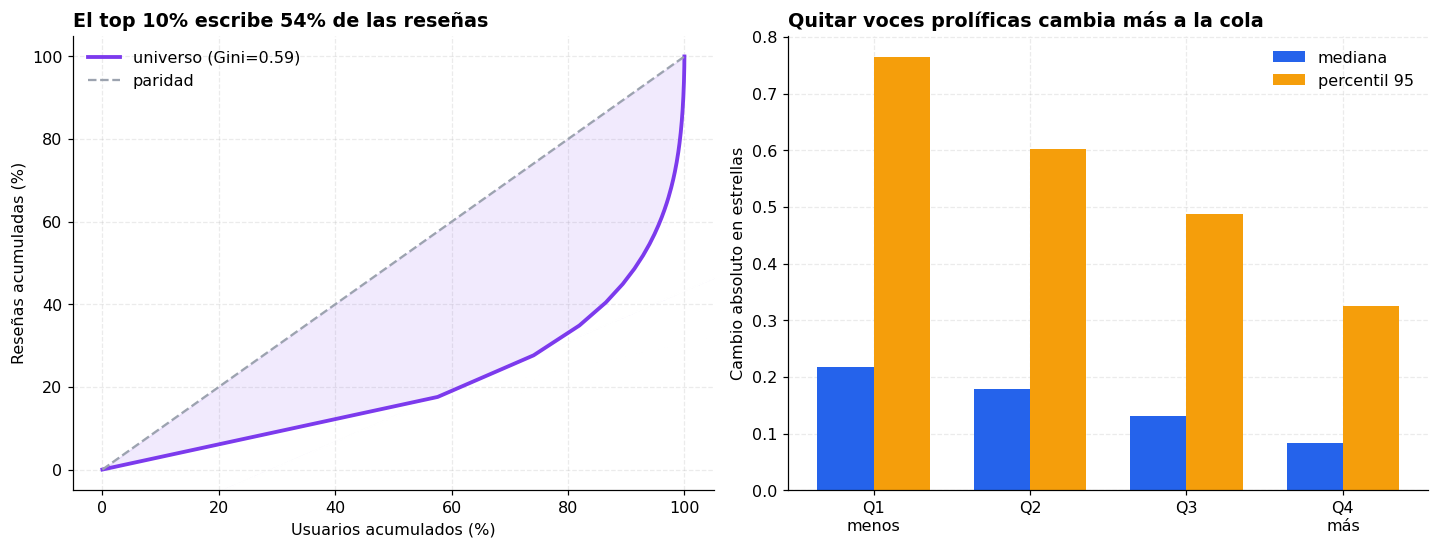

Usuarios con reseñas en el universo: 813,796
Gini=0.590 | share top 10%=54.0% | umbral top 10%=>6 reseñas
Negocios auditables=19,228 | mediana |Δ|=0.141 | p95=0.583


In [4]:
reviews_path = str(GOLD/"resenas_universo.parquet")
con = duckdb.connect()
actividad = con.execute(f'''
    SELECT user_id, count(*)::BIGINT AS n_reviews_usuario
    FROM read_parquet('{reviews_path}') GROUP BY user_id
''').df()
q90_activity = float(actividad.n_reviews_usuario.quantile(.90))

voz_negocio = con.execute(f'''
WITH ua AS (
    SELECT user_id, count(*) AS n_user
    FROM read_parquet('{reviews_path}') GROUP BY user_id
), b AS (
    SELECT r.business_id,
           count(*) AS n_all,
           avg(r.stars) AS mean_all,
           count(*) FILTER (WHERE ua.n_user <= {q90_activity}) AS n_nonprolific,
           avg(r.stars) FILTER (WHERE ua.n_user <= {q90_activity}) AS mean_nonprolific
    FROM read_parquet('{reviews_path}') r JOIN ua USING(user_id)
    GROUP BY r.business_id
)
SELECT * FROM b WHERE n_all >= 20 AND n_nonprolific >= 5
''').df()
voz_negocio["delta_sin_top10"] = voz_negocio.mean_nonprolific - voz_negocio.mean_all
pct = voz_negocio.n_all.rank(method="average", pct=True)
voz_negocio["volumen"] = np.select(
    [pct<=.25, pct<=.5, pct<=.75, pct>.75], ["Q1 menos reseñas", "Q2", "Q3", "Q4 más reseñas"],
    default="sin dato",
)

gini_universo = ca.gini(actividad.n_reviews_usuario)
share10_universo = ca.top_share(actividad.n_reviews_usuario, .10)
pop_lorenz, value_lorenz = ca.lorenz_curve(actividad.n_reviews_usuario)
sens = voz_negocio.groupby("volumen").delta_sin_top10.apply(
    lambda s: pd.Series({"mediana_abs":s.abs().median(), "p95_abs":s.abs().quantile(.95)})
).unstack()
orden_vol = ["Q1 menos reseñas", "Q2", "Q3", "Q4 más reseñas"]
sens = sens.reindex(orden_vol)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.1))
axes[0].plot(pop_lorenz*100, value_lorenz*100, color=P["morado"], lw=2.5, label=f"universo (Gini={gini_universo:.2f})")
axes[0].plot([0,100],[0,100], ls="--", color=P["gris"], label="paridad")
axes[0].fill_between(pop_lorenz*100, value_lorenz*100, pop_lorenz*100, color=P["morado"], alpha=.10)
axes[0].set_xlabel("Usuarios acumulados (%)"); axes[0].set_ylabel("Reseñas acumuladas (%)")
axes[0].set_title(f"El top 10% escribe {share10_universo:.0%} de las reseñas")
axes[0].legend()

x = np.arange(4)
axes[1].bar(x-.18, sens.mediana_abs, .36, color=P["azul"], label="mediana")
axes[1].bar(x+.18, sens.p95_abs, .36, color=P["naranja"], label="percentil 95")
axes[1].set_xticks(x); axes[1].set_xticklabels(["Q1\nmenos", "Q2", "Q3", "Q4\nmás"])
axes[1].set_ylabel("Cambio absoluto en estrellas")
axes[1].set_title("Quitar voces prolíficas cambia más a la cola")
axes[1].legend()
print(viz.guardar(fig, "parte7_concentracion_voz")); plt.show()

voz_negocio.to_parquet(GOLD/"auditoria_voz_usuarios.parquet", index=False)
print(f"Usuarios con reseñas en el universo: {len(actividad):,}")
print(f"Gini={gini_universo:.3f} | share top 10%={share10_universo:.1%} | umbral top 10%=>{q90_activity:.0f} reseñas")
print(f"Negocios auditables={len(voz_negocio):,} | mediana |Δ|={voz_negocio.delta_sin_top10.abs().median():.3f} | p95={voz_negocio.delta_sin_top10.abs().quantile(.95):.3f}")


### Interpretación
El resultado de Parte I se replica: en el dataset completo el Gini fue 0.61 y el top 10% produjo 56%; dentro de los tres mercados sigue siendo aproximadamente 0.59 y 54%. La selección geográfica no elimina la concentración.

Excluir a los prolíficos **no es una política propuesta**: sería injusto tratar actividad como fraude. Es una prueba de dependencia. Si el rating de negocios con pocas observaciones cambia mucho, rankings, clusters y recomendaciones heredan esa inestabilidad. La mitigación correcta es agregación robusta, intervalos de incertidumbre y detección de comportamiento coordinado, no silenciar automáticamente a quienes participan más.


## 4. Equidad de exposición en PageRank, HITS y popularidad

Medimos representación en el top 1% y top 5%. Un ratio 1 significa que la presencia del grupo en la cabeza coincide con su peso en el catálogo; 2 significa el doble. Es una auditoría descriptiva, no una prueba causal.


docs/figs/parte7_equidad_rankings.png


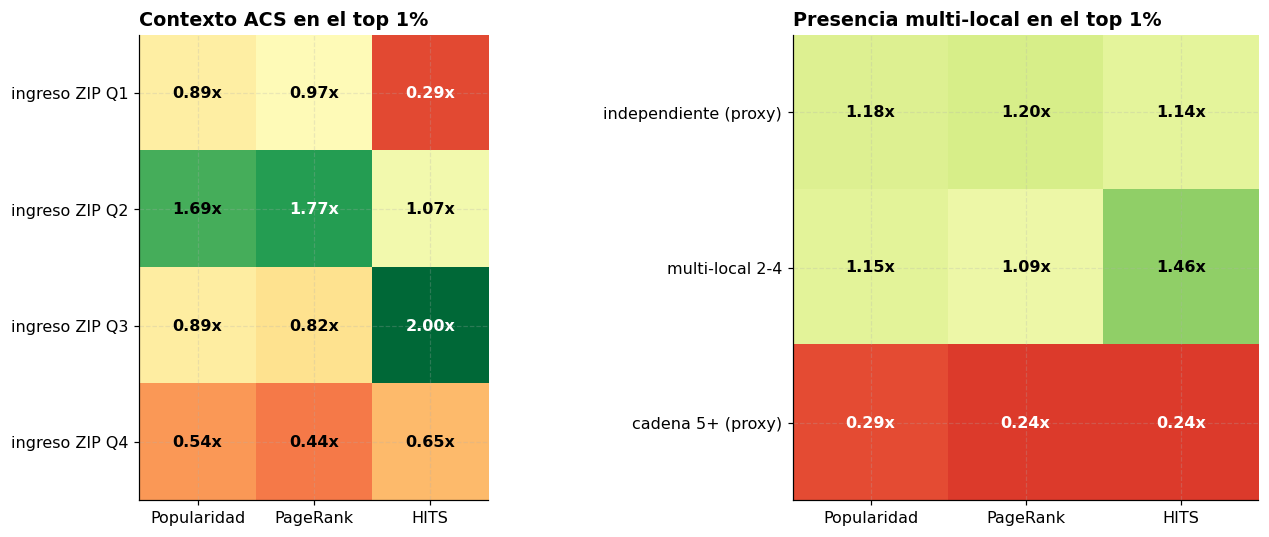

Correlación Spearman:


,review_count,pagerank_bip,hits_authority,mediana_ingreso
review_count,1.000,0.990,0.674,0.091
pagerank_bip,0.990,1.000,0.617,0.067
hits_authority,0.674,0.617,1.000,0.280
mediana_ingreso,0.091,0.067,0.280,1.000


In [5]:
ranking = pd.read_parquet(GOLD/"ranking_negocios.parquet")
income = pd.read_parquet(GOLD/"features_negocio.parquet", columns=["business_id", "mediana_ingreso"])
business_rank = ca.add_business_proxies(ranking.merge(income, on="business_id", how="left"))
auditoria_rank = ca.representation_audit(
    business_rank,
    score_columns=["review_count", "pagerank_bip", "hits_authority"],
    group_columns=["visibilidad", "tipo_nombre", "ingreso_zip"],
    top_fractions=(.01, .05),
)
auditoria_rank.to_parquet(GOLD/"auditoria_exposicion_rankings.parquet", index=False)

labels_metodo = {"review_count":"Popularidad", "pagerank_bip":"PageRank", "hits_authority":"HITS"}
def matrix_for(dimension, groups):
    z = auditoria_rank[(auditoria_rank.top_fraction==.01) & (auditoria_rank.dimension==dimension)]
    p = z.pivot(index="grupo", columns="ranking", values="ratio_representacion").reindex(groups)
    return p[["review_count", "pagerank_bip", "hits_authority"]]

income_order = ["ingreso ZIP Q1", "ingreso ZIP Q2", "ingreso ZIP Q3", "ingreso ZIP Q4"]
type_order = ["independiente (proxy)", "multi-local 2-4", "cadena 5+ (proxy)"]
mats = [matrix_for("ingreso_zip", income_order), matrix_for("tipo_nombre", type_order)]
titles = ["Contexto ACS en el top 1%", "Presencia multi-local en el top 1%"]

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0))
for ax, mat, title in zip(axes, mats, titles):
    im = ax.imshow(mat.to_numpy(), cmap="RdYlGn", vmin=0, vmax=2)
    ax.set_xticks(range(3)); ax.set_xticklabels([labels_metodo[c] for c in mat.columns])
    ax.set_yticks(range(len(mat))); ax.set_yticklabels(mat.index)
    ax.set_title(title)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            value = mat.iloc[i,j]
            ax.text(j, i, f"{value:.2f}x", ha="center", va="center", fontweight="bold", color="black" if .35<value<1.7 else "white")
fig.subplots_adjust(wspace=.55)
print(viz.guardar(fig, "parte7_equidad_rankings")); plt.show()

corr = business_rank[["review_count", "pagerank_bip", "hits_authority", "mediana_ingreso"]].corr(method="spearman")
print("Correlación Spearman:")
display(corr.round(3))


### Hallazgo: el problema es visibilidad, no simplemente “cadenas”
Los tres rankings concentran su top 1% en el cuartil de negocios con más reseñas. Sin embargo, el proxy de cadenas 5+ está **subrepresentado** y los independientes icónicos están sobrerrepresentados. La evidencia no permite decir “Yelp favorece cadenas”; permite decir algo más preciso: **favorece negocios que ya acumularon atención**, sean independientes o multi-locales.

HITS tiene una correlación mayor con ingreso del ZIP que PageRank y sobrerrepresenta el tercer cuartil de ingreso. Es coherente con su mecanismo: un restaurante gana autoridad si lo avalan hubs fuertes, y los hubs del estudio son reseñadores prolíficos/Elite. No demuestra discriminación, pero sí una ruta plausible de amplificación que debe monitorearse.


## 5. Recomendación: relevancia, cobertura y exposición

Reconstruimos el CF item-item de Parte IV y repetimos exactamente la cohorte temporal de 1,500 usuarios. Conservamos los 15,000 slots top-10 de CF y top-popular. Así la auditoría usa la evaluación completa, no los 150 ejemplos ilustrativos.


docs/figs/parte7_equidad_recomendacion.png


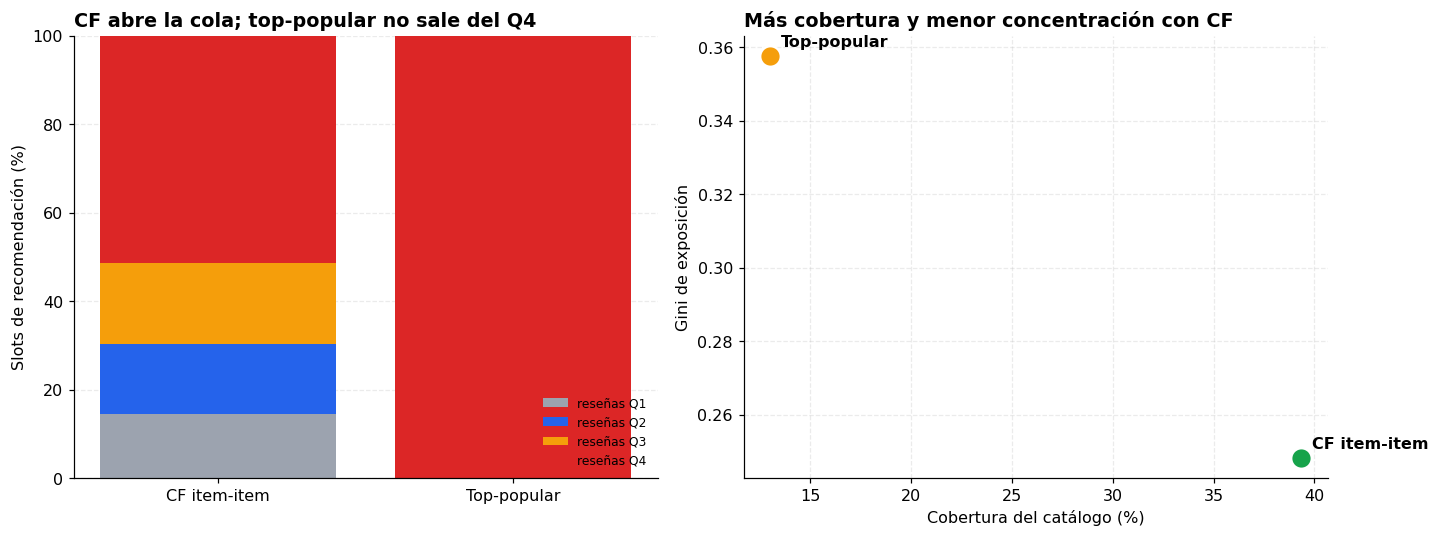

Reconstrucción CF: 9.66s


,slots,items_unicos,ratio_unicos,gini_exposicion,share_top10_items,modelo,cobertura_catalogo
0,15000,10210,0.680667,0.248270,0.0058,CF item-item,0.393419
1,15000,3374,0.224933,0.357678,0.0108,Top-popular,0.130009


,modelo,grupo,share_exposicion,ratio_representacion
0,CF item-item,reseñas Q4,0.513,1.892
1,CF item-item,reseñas Q2,0.158,0.633
2,CF item-item,reseñas Q3,0.183,0.740
3,CF item-item,reseñas Q1,0.146,0.629
12,Top-popular,reseñas Q4,1.000,3.688
13,Top-popular,reseñas Q2,0.000,0.000
14,Top-popular,reseñas Q3,0.000,0.001
15,Top-popular,reseñas Q1,0.000,0.000


In [6]:
t0 = perf_counter()
interactions = rec.cargar_interacciones()
train, val, test = rec.split_temporal(interactions)
M = rec.matriz_train(train)
nbrs = rec.similitud_item_item(M, min_coratings=5, shrink=50.0, topk=40, cap_user=50)
cf_build_seconds = perf_counter()-t0
uindptr, uitems, uratings = rec.usuario_csr(M)
u2x, i2x = M["u2x"], M["i2x"]
counts_u = pd.Series(M["ux"]).value_counts()
warm = set(counts_u[counts_u>=3].index)

neg = pd.read_parquet(GOLD/"negocios_universo.parquet", columns=["business_id", "name", "review_count", "metro"])
feat_income = pd.read_parquet(GOLD/"features_negocio.parquet", columns=["business_id", "mediana_ingreso"])
business_meta = ca.add_business_proxies(neg.merge(feat_income, on="business_id", how="left"))
b2m = dict(zip(business_meta.business_id, business_meta.metro))
i_metro = np.array([b2m.get(b, "?") for b in M["items"]])
metro_items = {m:np.where(i_metro==m)[0] for m in pd.unique(i_metro)}
pop = rec.popularidad(M)

def candidate_sets(split, n=1500, seed=SEED):
    rng = np.random.default_rng(seed)
    s = split[split.user_id.isin(u2x) & split.business_id.isin(i2x)].copy()
    s["uidx"] = s.user_id.map(u2x); s["iidx"] = s.business_id.map(i2x)
    s = s[s.uidx.isin(warm) & (s.stars>=4)]
    positives = s.groupby("uidx")["iidx"].apply(lambda x:list(set(x)))
    users = list(positives.index); rng.shuffle(users); result=[]
    for u in users:
        a,b = uindptr[u],uindptr[u+1]; seen=set(uitems[a:b].tolist())
        pos=[i for i in positives[u] if i not in seen]
        if not pos: continue
        mode=pd.Series(i_metro[uitems[a:b]]).mode(); market=mode.iloc[0] if len(mode) else i_metro[pos[0]]
        negs=[i for i in rng.choice(metro_items[market], size=min(99,len(metro_items[market])), replace=False).tolist() if i not in seen and i not in pos][:99]
        result.append((u, np.array(pos+negs), uitems[a:b], uratings[a:b]))
        if len(result)>=n: break
    return result

def cf_scores(candidates, seen_items, seen_ratings):
    liked=set(seen_items[seen_ratings>=4].tolist()); out=np.zeros(len(candidates))
    for z,i in enumerate(candidates):
        a,b=nbrs["indptr"][i],nbrs["indptr"][i+1]
        out[z]=sum(s for v,s in zip(nbrs["vecino"][a:b].tolist(),nbrs["sim"][a:b].tolist()) if v in liked)
    return out

exposure_idx = {"CF item-item":[], "Top-popular":[]}
for u, candidates, seen_i, seen_r in candidate_sets(test):
    exposure_idx["CF item-item"] += candidates[np.argsort(-cf_scores(candidates,seen_i,seen_r))[:10]].tolist()
    exposure_idx["Top-popular"] += candidates[np.argsort(-pop[candidates])[:10]].tolist()

eligible = business_meta.set_index("business_id").loc[np.asarray(M["items"])]
rows=[]; concentrations=[]
for model, idxs in exposure_idx.items():
    bids=np.asarray(M["items"])[np.asarray(idxs)]
    shown=business_meta.set_index("business_id").loc[bids]
    c=ca.concentration_summary(bids); c.update(modelo=model, cobertura_catalogo=len(set(bids))/M["n_items"])
    concentrations.append(c)
    for dimension in ["visibilidad", "tipo_nombre", "ingreso_zip"]:
        base=eligible[dimension].value_counts(normalize=True); observed=shown[dimension].value_counts(normalize=True)
        for group, base_share in base.items():
            share=float(observed.get(group,0))
            rows.append([model, dimension, group, base_share, share, share/base_share if base_share else np.nan])

audit_rec = pd.DataFrame(rows, columns=["modelo","dimension","grupo","share_catalogo_elegible","share_exposicion","ratio_representacion"])
concentration_rec = pd.DataFrame(concentrations)
audit_rec = audit_rec.merge(concentration_rec[["modelo","cobertura_catalogo","gini_exposicion","items_unicos"]], on="modelo")
audit_rec.to_parquet(GOLD/"auditoria_recomendacion_exposicion.parquet", index=False)

vis_order=["reseñas Q1","reseñas Q2","reseñas Q3","reseñas Q4"]
vis=audit_rec[audit_rec.dimension=="visibilidad"].pivot(index="modelo",columns="grupo",values="share_exposicion").reindex(columns=vis_order).fillna(0)
fig, axes=plt.subplots(1,2,figsize=(13.2,5.0))
bottom=np.zeros(len(vis))
colors=[P["gris"],P["azul"],P["naranja"],P["rojo"]]
for col,color in zip(vis.columns,colors):
    axes[0].bar(vis.index,vis[col]*100,bottom=bottom*100,label=col,color=color)
    bottom+=vis[col].to_numpy()
axes[0].set_ylabel("Slots de recomendación (%)"); axes[0].set_ylim(0,100)
axes[0].set_title("CF abre la cola; top-popular no sale del Q4")
axes[0].legend(fontsize=8,loc="lower right")

for _,r in concentration_rec.iterrows():
    color=P["verde"] if r.modelo.startswith("CF") else P["naranja"]
    axes[1].scatter(r.cobertura_catalogo*100,r.gini_exposicion,s=180,color=color,edgecolor="white",lw=1.5)
    axes[1].annotate(r.modelo,(r.cobertura_catalogo*100,r.gini_exposicion),xytext=(7,6),textcoords="offset points",fontweight="bold")
axes[1].set_xlabel("Cobertura del catálogo (%)"); axes[1].set_ylabel("Gini de exposición")
axes[1].set_title("Más cobertura y menor concentración con CF")
print(viz.guardar(fig,"parte7_equidad_recomendacion")); plt.show()

print(f"Reconstrucción CF: {cf_build_seconds:.2f}s")
display(concentration_rec)
display(audit_rec[(audit_rec.dimension=="visibilidad")][["modelo","grupo","share_exposicion","ratio_representacion"]].round(3))


### Interpretación
El CF mejora simultáneamente utilidad y distribución: alcanza NDCG@10 0.491, cubre 39.3% del catálogo y muestra 10,210 negocios distintos; top-popular cubre 13.0% y muestra 3,374. Pero CF no logra paridad: el Q4 de visibilidad ocupa aproximadamente 51% de los slots aunque representa cerca de 25% del catálogo elegible.

La recomendación personalizada **reduce** el sesgo de popularidad, no lo resuelve. Una política defendible añadiría objetivos explícitos de exposición -por ejemplo, reranking con diversidad, límites de repetición y un pequeño componente de exploración- y vigilaría NDCG junto con cobertura, Gini y ratios por grupo.


## 6. Reseñas falsas: prueba de estrés, no detector de fraude

Yelp no trae una etiqueta confiable de “spam”. Inventarla sería metodológicamente incorrecto. En su lugar simulamos qué ocurriría si una campaña de 5, 20 o 100 reseñas coordinadas de 1 o 5 estrellas atravesara los controles. La prueba aísla vulnerabilidad; no acusa a ningún usuario real.


docs/figs/parte7_sensibilidad_spam.png


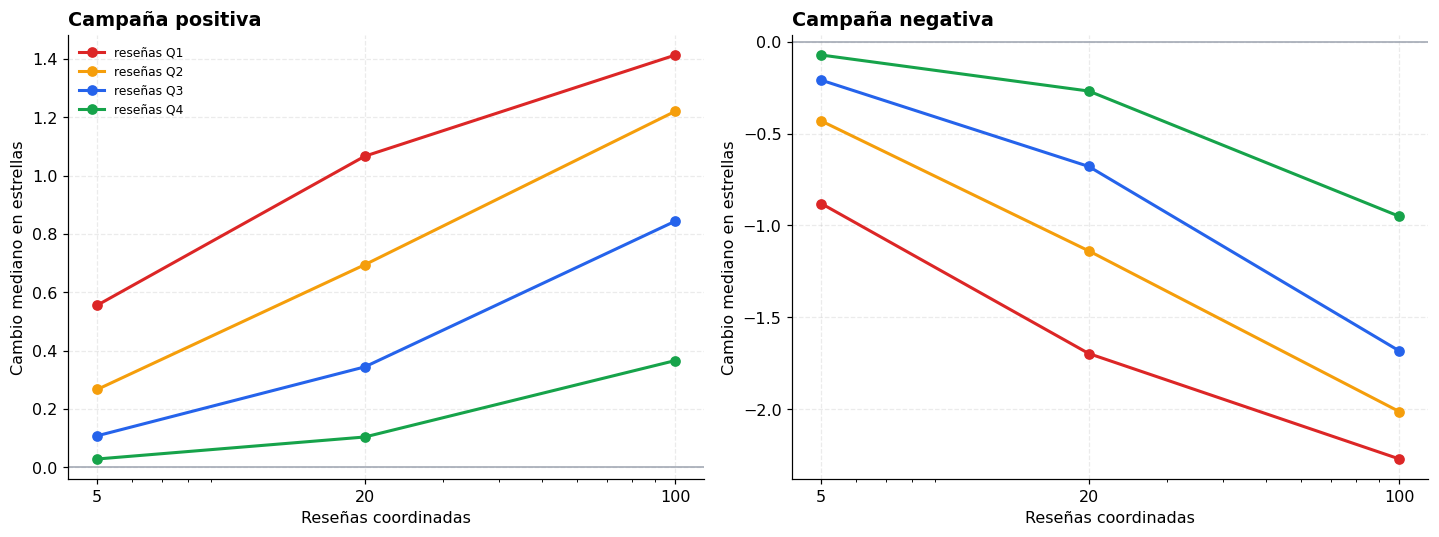

,tipo_ataque,n_falsas,visibilidad,negocios,delta_mediana,delta_abs_p90,pct_cruza_4
0,1 estrellas,5,reseñas Q1,7564,-0.881,1.442,31.861
1,1 estrellas,5,reseñas Q2,7145,-0.432,0.683,22.967
2,1 estrellas,5,reseñas Q3,7298,-0.210,0.333,13.716
3,1 estrellas,5,reseñas Q4,7307,-0.073,0.133,6.158
4,1 estrellas,20,reseñas Q1,7564,-1.696,2.560,31.861
5,1 estrellas,20,reseñas Q2,7145,-1.138,1.667,28.286
6,1 estrellas,20,reseñas Q3,7298,-0.679,1.014,31.255
7,1 estrellas,20,reseñas Q4,7307,-0.269,0.472,22.691
8,1 estrellas,100,reseñas Q1,7564,-2.270,3.276,31.861
9,1 estrellas,100,reseñas Q2,7145,-2.012,2.816,28.286


In [7]:
business_stats = con.execute(f'''
    SELECT business_id, count(*)::BIGINT AS n_reviews, avg(stars) AS mean_stars
    FROM read_parquet('{reviews_path}') GROUP BY business_id
''').df()
spam_detail, spam_summary = ca.review_attack_stress(business_stats, attacks=(5,20,100), target_stars=(1.,5.))
spam_summary.to_parquet(GOLD/"stress_spam_ratings.parquet", index=False)

fig, axes=plt.subplots(1,2,figsize=(13.2,5.0),sharey=False)
visibility_order=["reseñas Q1","reseñas Q2","reseñas Q3","reseñas Q4"]
color_q={q:c for q,c in zip(visibility_order,[P["rojo"],P["naranja"],P["azul"],P["verde"]])}
for ax, attack, title in zip(axes,["5 estrellas","1 estrellas"],["Campaña positiva","Campaña negativa"]):
    z=spam_summary[spam_summary.tipo_ataque==attack]
    for q in visibility_order:
        qz=z[z.visibilidad==q].sort_values("n_falsas")
        ax.plot(qz.n_falsas,qz.delta_mediana,marker="o",lw=2,label=q,color=color_q[q])
    ax.axhline(0,color=P["gris"],lw=1); ax.set_xscale("log"); ax.set_xticks([5,20,100]); ax.set_xticklabels([5,20,100])
    ax.set_xlabel("Reseñas coordinadas"); ax.set_ylabel("Cambio mediano en estrellas"); ax.set_title(title)
axes[0].legend(fontsize=8)
print(viz.guardar(fig,"parte7_sensibilidad_spam")); plt.show()
display(spam_summary.round(3))


### Hallazgo
Cinco reseñas de 5 estrellas mueven la mediana del Q1 alrededor de **+0.56 estrellas**, frente a solo +0.03 en Q4. La misma cantidad de reseñas negativas reduce Q1 cerca de **-0.88**. Los negocios con menos historia son quienes más necesitan exposición y, a la vez, quienes tienen el promedio más frágil.

Mitigaciones: promedio bayesiano con incertidumbre; peso decreciente para ráfagas correlacionadas; detección de cuentas/cohortes coordinadas; revisión humana para sanciones; y separación entre señal de ranking y conteo bruto. El sistema debe evitar el error ético de convertir un indicador de riesgo en una acusación automática.


## 7. Clustering y contexto socioeconómico: medir sin cometer falacia ecológica

ACS describe el ZIP, no a clientes ni propietarios. Aun así, permite detectar si la calidad de representación de Yelp cambia por contexto. Medimos cobertura de atributos y composición de los seis clusters por cuartil de ingreso ZIP.


docs/figs/parte7_sesgo_contexto_clusters.png


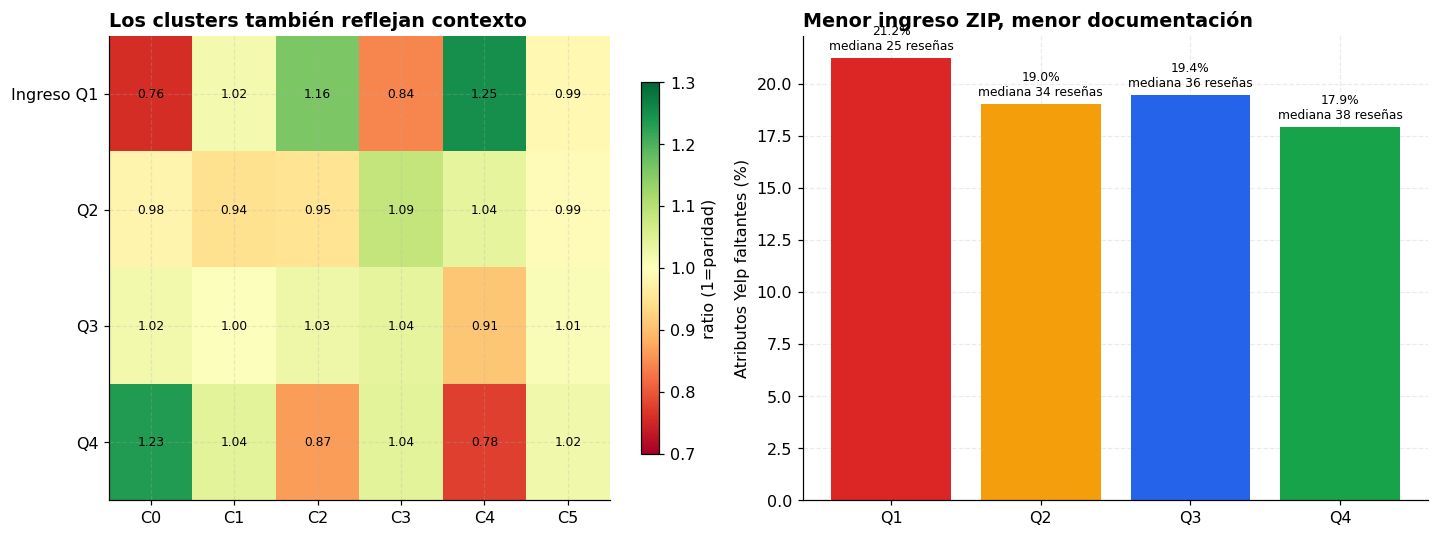

,ingreso_zip,negocios,estrellas_media,resenas_mediana,faltantes_media
0,ingreso ZIP Q1,7261,3.519,25.0,0.212
1,ingreso ZIP Q2,7269,3.546,34.0,0.190
2,ingreso ZIP Q3,7435,3.564,36.0,0.194
3,ingreso ZIP Q4,7058,3.530,38.0,0.179
4,ingreso ZIP sin dato,291,3.555,21.0,0.214


In [8]:
features = pd.read_parquet(GOLD/"features_negocio.parquet")
names = pd.read_parquet(GOLD/"negocios_universo.parquet", columns=["business_id","name"])
clusters = pd.read_parquet(GOLD/"clusters_negocio.parquet")
context = ca.add_business_proxies(features.merge(names,on="business_id").merge(clusters,on="business_id"))
audited_attrs=["price_range","alcohol","wifi","RestaurantsTakeOut","BusinessAcceptsCreditCards","RestaurantsDelivery","RestaurantsReservations","OutdoorSeating","HasTV","RestaurantsGoodForGroups","GoodForKids","BikeParking","Caters","RestaurantsTableService","parking_alguno","amb_alguno","meal_alguno"]
context["missing_rate"] = context[audited_attrs].isna().mean(axis=1)
context_summary = context.groupby("ingreso_zip",observed=True).agg(
    negocios=("business_id","size"), estrellas_media=("stars","mean"),
    resenas_mediana=("review_count","median"), faltantes_media=("missing_rate","mean")
).reset_index()
cluster_share=pd.crosstab(context.ingreso_zip,context.cluster_kmeans,normalize="index")
cluster_base=context.cluster_kmeans.value_counts(normalize=True).sort_index()
cluster_ratio=cluster_share.divide(cluster_base,axis=1)
cluster_long=cluster_ratio.stack().rename("ratio_representacion").reset_index()
context_summary.to_parquet(GOLD/"auditoria_contexto_clusters.parquet",index=False)
cluster_long.to_parquet(GOLD/"representacion_clusters_ingreso.parquet",index=False)

income_order=["ingreso ZIP Q1","ingreso ZIP Q2","ingreso ZIP Q3","ingreso ZIP Q4"]
heat=cluster_ratio.reindex(income_order)
summary_plot=context_summary.set_index("ingreso_zip").reindex(income_order)
fig,axes=plt.subplots(1,2,figsize=(13.2,5.0))
im=axes[0].imshow(heat,cmap="RdYlGn",vmin=.7,vmax=1.3,aspect="auto")
axes[0].set_xticks(range(6));axes[0].set_xticklabels([f"C{i}" for i in range(6)])
axes[0].set_yticks(range(4));axes[0].set_yticklabels(["Ingreso Q1","Q2","Q3","Q4"])
axes[0].set_title("Los clusters también reflejan contexto")
for i in range(4):
    for j in range(6): axes[0].text(j,i,f"{heat.iloc[i,j]:.2f}",ha="center",va="center",fontsize=8)
fig.colorbar(im,ax=axes[0],shrink=.8,label="ratio (1=paridad)")

axes[1].bar(range(4),summary_plot.faltantes_media*100,color=[P["rojo"],P["naranja"],P["azul"],P["verde"]])
axes[1].set_xticks(range(4));axes[1].set_xticklabels(["Q1","Q2","Q3","Q4"])
axes[1].set_ylabel("Atributos Yelp faltantes (%)");axes[1].set_title("Menor ingreso ZIP, menor documentación")
for i,(miss,rev) in enumerate(zip(summary_plot.faltantes_media*100,summary_plot.resenas_mediana)):
    axes[1].text(i,miss+.4,f"{miss:.1f}%\nmediana {rev:.0f} reseñas",ha="center",fontsize=8)
print(viz.guardar(fig,"parte7_sesgo_contexto_clusters"));plt.show()
display(context_summary.round(3))


### Hallazgo
Los negocios en ZIPs del cuartil inferior tienen mediana de 25 reseñas frente a 38 en Q4 y aproximadamente 21.2% de atributos faltantes frente a 17.9%. También aparecen más en los segmentos de baja información y baja tracción. Parte de lo que clustering llama “perfil operativo” puede ser **calidad desigual de documentación**.

Esto no invalida los clusters: indica cómo usarlos. Son herramientas descriptivas para explorar, no etiquetas de mérito ni decisiones automáticas de crédito, inspección o inversión. Deben acompañarse de indicadores de missingness y análisis de sensibilidad sin ACS.


## 8. Riesgos, mitigaciones y transferibilidad a Lima

La transferencia no consiste en copiar parámetros. Consiste en conservar el método y volver a validar fuentes, lenguaje, geografía, comportamiento y criterios de equidad.


In [9]:
riesgos = pd.DataFrame([
    ["Representación", "Pocos usuarios producen gran parte de las reseñas", "Alta", "Gini + sensibilidad sin top 10%", "agregación robusta e intervalos"],
    ["Popularidad", "La exposición previa alimenta nueva exposición", "Alta", "ratios por visibilidad + cobertura", "reranking diverso y exploración"],
    ["Spam", "Campañas afectan más a negocios con poca historia", "Alta", "stress test 1/5 estrellas", "Bayes + detección coordinada + revisión"],
    ["Contexto", "Faltantes y ACS pueden definir clusters", "Media-alta", "missingness e ingreso ZIP", "indicadores de faltantes + ablación ACS"],
    ["Privacidad", "Texto, ubicación y red social pueden reidentificar", "Alta", "revisión de campos publicados", "agregar resultados; no publicar datos Yelp"],
    ["Drift", "Pandemia rompe el régimen histórico", "Alta", "COVID/DGIM y split temporal", "monitoreo y recalibración temporal"],
    ["Aproximación", "CMS/DGIM/SVD pierden información", "Media", "cota/error/energía", "publicar garantía y fallback exacto"],
    ["Proxy", "ZIP y nombre no son atributos individuales/propiedad", "Alta", "limitación explícita", "no usar para decisiones individuales"],
], columns=["familia","riesgo","severidad","evidencia","mitigacion"])

transfer = pd.DataFrame([
    ["Ingesta/EDA", "portable", "Reemplazar taxonomía Yelp y auditar cobertura local"],
    ["Grafos", "portable con nueva fuente", "Se necesita una red o bipartito con consentimiento y claves estables"],
    ["Clustering", "recalibrar", "Sustituir ACS por INEI/municipal; validar geocodificación y missingness"],
    ["Recomendación", "reentrenar", "Tokenización en español, nueva matriz y protocolo temporal"],
    ["Streams", "portable", "Definir eventos, zona America/Lima, feriados y shocks locales"],
    ["PCA/SVD", "reajustar", "Los factores latentes dependen del vocabulario y distribución local"],
    ["Equidad", "rediseñar con actores locales", "Definir daño, grupos y objetivos con contexto peruano; no importar proxies"],
], columns=["componente","grado_transferencia","condicion"])

contribuciones.to_parquet(GOLD/"contribuciones_partes.parquet",index=False)
riesgos.to_parquet(GOLD/"matriz_riesgos_eticos.parquet",index=False)
transfer.to_parquet(GOLD/"matriz_transferibilidad_lima.parquet",index=False)
display(riesgos)
display(transfer)


,familia,riesgo,severidad,evidencia,mitigacion
0,Representación,Pocos usuarios producen gran parte de las reseñas,Alta,Gini + sensibilidad sin top 10%,agregación robusta e intervalos
1,Popularidad,La exposición previa alimenta nueva exposición,Alta,ratios por visibilidad + cobertura,reranking diverso y exploración
2,Spam,Campañas afectan más a negocios con poca historia,Alta,stress test 1/5 estrellas,Bayes + detección coordinada + revisión
3,Contexto,Faltantes y ACS pueden definir clusters,Media-alta,missingness e ingreso ZIP,indicadores de faltantes + ablación ACS
4,Privacidad,"Texto, ubicación y red social pueden reidentif...",Alta,revisión de campos publicados,agregar resultados; no publicar datos Yelp
5,Drift,Pandemia rompe el régimen histórico,Alta,COVID/DGIM y split temporal,monitoreo y recalibración temporal
6,Aproximación,CMS/DGIM/SVD pierden información,Media,cota/error/energía,publicar garantía y fallback exacto
7,Proxy,ZIP y nombre no son atributos individuales/pro...,Alta,limitación explícita,no usar para decisiones individuales


,componente,grado_transferencia,condicion
0,Ingesta/EDA,portable,Reemplazar taxonomía Yelp y auditar cobertura ...
1,Grafos,portable con nueva fuente,Se necesita una red o bipartito con consentimi...
2,Clustering,recalibrar,Sustituir ACS por INEI/municipal; validar geoc...
3,Recomendación,reentrenar,"Tokenización en español, nueva matriz y protoc..."
4,Streams,portable,"Definir eventos, zona America/Lima, feriados y..."
5,PCA/SVD,reajustar,Los factores latentes dependen del vocabulario...
6,Equidad,rediseñar con actores locales,"Definir daño, grupos y objetivos con contexto ..."


## Conclusiones integradas

1. **La arquitectura sí escala cuando cambia la representación.** Parquet/CSR/bloques reducen memoria; BFR, CMS, DGIM y SVD cambian el régimen de cómputo. DBSCAN y Girvan-Newman siguen limitados porque bloquear memoria no elimina su crecimiento cuadrático/cúbico.
2. **La mejor precisión no basta.** CF es el mejor ranking y distribuye exposición mucho mejor que top-popular, pero todavía sobrerrepresenta negocios ya visibles. NDCG debe convivir con cobertura, concentración y representación.
3. **La desigualdad aparece antes del modelo.** Un grupo pequeño produce gran parte de las reseñas; negocios de contextos menos favorecidos tienen menos reseñas y más atributos faltantes. El modelo hereda esa historia.
4. **No encontramos evidencia de una ventaja general para cadenas.** Los rankings favorecen atención acumulada y, en este universo, muchos ganadores son independientes icónicos. La formulación correcta es visibilidad vs cola larga, no cadena vs independiente como conclusión automática.
5. **Los pequeños/menos visibles son más vulnerables a manipulación.** La misma campaña simulada cambia mucho más sus ratings; por eso la defensa contra spam también es una política de equidad.
6. **Transferir a Lima exige nuevos datos y nueva validación.** La metodología es portable; los parámetros, vocabulario, fuentes ACS y proxies no lo son.

### Limitaciones que deben quedar en el informe
- No hay atributos protegidos ni ground truth de spam: auditamos proxies y vulnerabilidad, no discriminación causal ni fraude real.
- El ingreso es del ZIP (falacia ecológica si se atribuye a individuos).
- Repetir nombre no prueba propiedad de cadena y puede mezclar franquicias/homónimos.
- La auditoría evalúa el período 2005-2021 de Yelp; pandemia y cambios de plataforma producen drift.
- Las métricas de equidad describen exposición del sistema; decidir qué nivel es justo requiere criterios normativos y participación de actores afectados.


In [10]:
expected_tables = [
    "benchmark_escalabilidad.parquet", "escalabilidad_algoritmos.parquet", "huella_memoria.parquet",
    "auditoria_voz_usuarios.parquet", "auditoria_exposicion_rankings.parquet",
    "auditoria_recomendacion_exposicion.parquet", "stress_spam_ratings.parquet",
    "auditoria_contexto_clusters.parquet", "representacion_clusters_ingreso.parquet",
    "contribuciones_partes.parquet", "matriz_riesgos_eticos.parquet", "matriz_transferibilidad_lima.parquet",
]
expected_figs = [
    "parte7_escalabilidad_tradeoffs.png", "parte7_concentracion_voz.png",
    "parte7_equidad_rankings.png", "parte7_equidad_recomendacion.png",
    "parte7_sensibilidad_spam.png", "parte7_sesgo_contexto_clusters.png",
]
check = pd.DataFrame({
    "artefacto": expected_tables + expected_figs,
    "existe": [(GOLD/x).exists() for x in expected_tables] + [(ROOT/"docs"/"figs"/x).exists() for x in expected_figs],
})
display(check)
assert check.existe.all(), "Falta al menos un artefacto de Parte VII"
print(f"Parte VII materializada: {len(expected_tables)} tablas + {len(expected_figs)} figuras.")


,artefacto,existe
0,benchmark_escalabilidad.parquet,True
1,escalabilidad_algoritmos.parquet,True
2,huella_memoria.parquet,True
3,auditoria_voz_usuarios.parquet,True
4,auditoria_exposicion_rankings.parquet,True
5,auditoria_recomendacion_exposicion.parquet,True
6,stress_spam_ratings.parquet,True
7,auditoria_contexto_clusters.parquet,True
8,representacion_clusters_ingreso.parquet,True
9,contribuciones_partes.parquet,True


Parte VII materializada: 12 tablas + 6 figuras.


## Resumen del notebook

**Parte VII cerrada cuando este notebook corre de principio a fin.** Auditamos escalabilidad con complejidad, memoria, tiempos y un benchmark sobre datos reales; cuantificamos concentración de voz y sensibilidad a usuarios prolíficos; medimos exposición de PageRank/HITS/CF/top-popular; simulamos manipulación de ratings; revisamos clustering por contexto ACS; y dejamos riesgos, mitigaciones y condiciones de transferencia a Lima. Las conclusiones distinguen evidencia descriptiva, proxies y límites causales.
